# Install Library

In [ ]:
!pip install mealpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.8/168.8 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.5/58.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.3/423.3 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 40.5 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.0 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.0 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1

In [ ]:
!pip install opfunu

# Import Library

In [ ]:
# fundamental libraries
import os
import time
import numpy as np
import pandas as pd
from pathlib import Path

# mealpy library
from mealpy import Multitask

from typing import List, Dict

# Connected to Drive

In [1]:
from google.colab import drive

# This will prompt for authorization.
# Make sure to follow the instructions and paste the authorization code.
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
path = "/content/drive/My Drive/Revision/"

# Define Necessary Function

## Benchmark Function

In [ ]:
import sys
sys.path.append(path)

from benchmark_functions import classical_test_function
from benchmark_functions import cec20_test_function_with_bias
from benchmark_functions import cec22_test_function_with_bias

## Define Problems

In [ ]:
# Classical Test Function
Fnames, Ffunctions, Fproblems, Flatexs = classical_test_function()

In [ ]:
# Composite (CEC20) Test Function
C20names_50, C20functions_50, C20problems_50, C20latexs_50 = cec20_test_function_with_bias(dimension=50)
C20names_100, C20functions_100, C20problems_100, C20latexs_100 = cec20_test_function_with_bias(dimension=100)

In [ ]:
# Composite (CEC22) Test Function
C22names_10, C22functions_10, C22problems_10, C22latexs_10 = cec22_test_function_with_bias(dimension=10)
C22names_20, C22functions_20, C22problems_20, C22latexs_20 = cec22_test_function_with_bias(dimension=20)

# Define Models

In [ ]:
from optimizers import NHO

try:
    from optimizers import NHO_NoDopamine
except Exception:
    NHO_NoDopamine = None

try:
    from optimizers import NHO_NoSerotonin
except Exception:
    NHO_NoSerotonin = None

try:
    from optimizers import NHO_NoCortisol
except Exception:
    NHO_NoCortisol = None

try:
    from optimizers import NHO_NoHomeostasis
except Exception:
    NHO_NoHomeostasis = None

# Selected Benchmark Functions

In [ ]:
def select_problem_list(name_list, problem_list, selected_index):
    selected_names = []
    selected_problems = []

    for idx in selected_index:
        selected_names.append(name_list[idx])
        selected_problems.append(problem_list[idx])

    return selected_names, selected_problems

In [ ]:
# 0-based index kullanılmıştır.
# Ablation için tüm benchmarklar yerine temsilci ve zor fonksiyonlar seçilmiştir.
# İstersen buradaki indeksleri değiştirerek farklı fonksiyonlar seçebilirsin.

classic_selected_index = [0, 6, 9, 14]
cec22_10_selected_index = [2, 4, 8, 11]
cec22_20_selected_index = [2, 4, 8, 11]

Fnames_sel, Fproblems_sel = select_problem_list(Fnames, Fproblems, classic_selected_index)
C22names_10_sel, C22problems_10_sel = select_problem_list(C22names_10, C22problems_10, cec22_10_selected_index)
C22names_20_sel, C22problems_20_sel = select_problem_list(C22names_20, C22problems_20, cec22_20_selected_index)

print("Selected Classical Functions:", Fnames_sel)
print("Selected CEC22-10 Functions:", C22names_10_sel)
print("Selected CEC22-20 Functions:", C22names_20_sel)

Selected Classical Functions: ['F1', 'F7', 'F10', 'F15']
Selected CEC22-10 Functions: ['C3', 'C5', 'C9', 'C12']
Selected CEC22-20 Functions: ['C3', 'C5', 'C9', 'C12']


# Ablation Analysis

In [ ]:
# Hızlı çalışma için 3 kullanılabilir.
# Daha güvenli sonuç için 5 önerilir.
trial = 5
n_workers = 4

ablation_results = []

In [ ]:
model_list = [
    ("NHO", NHO),
    ("NHO_NoDopamine", NHO_NoDopamine),
    ("NHO_NoSerotonin", NHO_NoSerotonin),
    ("NHO_NoCortisol", NHO_NoCortisol),
    ("NHO_NoHomeostasis", NHO_NoHomeostasis),
]

model_list = [(name, model_class) for name, model_class in model_list if model_class is not None]

if len(model_list) <= 1:
    raise ImportError("Ablation varyantları bulunamadı.")

model_list

[('NHO', optimizers.NHO),
 ('NHO_NoDopamine', optimizers.NHO_NoDopamine),
 ('NHO_NoSerotonin', optimizers.NHO_NoSerotonin),
 ('NHO_NoCortisol', optimizers.NHO_NoCortisol),
 ('NHO_NoHomeostasis', optimizers.NHO_NoHomeostasis)]

In [ ]:
def modify_problem_dicts(problem_list):
    modified_problems = []
    for problem_dict in problem_list:
        new_problem_dict = problem_dict.copy()
        if "fit_func" in new_problem_dict:
            new_problem_dict["obj_func"] = new_problem_dict.pop("fit_func")
        modified_problems.append(new_problem_dict)
    return modified_problems

In [ ]:
def run_selected_ablation_suite(suite_name, dimension, problem_list, epoch, pop_size):

    modified_problems = modify_problem_dicts(problem_list)

    for model_name, model_class in model_list:
        model = model_class(epoch=epoch, pop_size=pop_size)

        save_folder = path + f"history/ablation_selected/{suite_name}-{dimension}D/{model_name}"
        os.makedirs(save_folder, exist_ok=True)

        start_time = time.time()
        multitask = Multitask(algorithms=[model], problems=modified_problems, n_workers=n_workers)
        multitask.execute(n_trials=trial, save_path=save_folder, save_as="csv", save_convergence=True, verbose=True)
        runtime = time.time() - start_time

        ablation_results.append({
            "algorithm": model_name,
            "suite": suite_name,
            "dimension": dimension,
            "epoch": epoch,
            "pop_size": pop_size,
            "trial": trial,
            "runtime": runtime,
            "save_folder": save_folder
        })

        os.makedirs(path + "history/ablation_selected/", exist_ok=True)
        pd.DataFrame(ablation_results).to_csv(path + "history/ablation_selected/ablation_selected_runtime.csv", index=False)
        print("Completed", suite_name, dimension, model_name, "Runtime", runtime)

## Classical Selected Functions

In [ ]:
pop_size = 30
epoch = 100

if __name__ == "__main__":
    run_selected_ablation_suite("classic_selected", 2, Fproblems_sel, epoch, pop_size)

Solving problem: Ackley2 using algorithm: NHO, on the: 1 trial
Solving problem: Ackley2 using algorithm: NHO, on the: 2 trial
Solving problem: Ackley2 using algorithm: NHO, on the: 3 trial
Solving problem: Ackley2 using algorithm: NHO, on the: 4 trial
Solving problem: Ackley2 using algorithm: NHO, on the: 5 trial
Solving problem: Michalewicz using algorithm: NHO, on the: 1 trial
Solving problem: Michalewicz using algorithm: NHO, on the: 2 trial
Solving problem: Michalewicz using algorithm: NHO, on the: 3 trial
Solving problem: Michalewicz using algorithm: NHO, on the: 4 trial
Solving problem: Michalewicz using algorithm: NHO, on the: 5 trial
Solving problem: Langermann using algorithm: NHO, on the: 1 trial
Solving problem: Langermann using algorithm: NHO, on the: 2 trial
Solving problem: Langermann using algorithm: NHO, on the: 3 trial
Solving problem: Langermann using algorithm: NHO, on the: 4 trial
Solving problem: Langermann using algorithm: NHO, on the: 5 trial
Solving problem: Him

## CEC22-10 Selected Functions

In [ ]:
pop_size = 40
epoch = 200

if __name__ == "__main__":
    run_selected_ablation_suite("CEC22_selected", 10, C22problems_10_sel, epoch, pop_size)

Solving problem: F32022 using algorithm: NHO, on the: 1 trial
Solving problem: F32022 using algorithm: NHO, on the: 2 trial
Solving problem: F32022 using algorithm: NHO, on the: 3 trial
Solving problem: F32022 using algorithm: NHO, on the: 4 trial
Solving problem: F32022 using algorithm: NHO, on the: 5 trial
Solving problem: F52022 using algorithm: NHO, on the: 1 trial
Solving problem: F52022 using algorithm: NHO, on the: 2 trial
Solving problem: F52022 using algorithm: NHO, on the: 3 trial
Solving problem: F52022 using algorithm: NHO, on the: 4 trial
Solving problem: F52022 using algorithm: NHO, on the: 5 trial
Solving problem: F92022 using algorithm: NHO, on the: 1 trial
Solving problem: F92022 using algorithm: NHO, on the: 2 trial
Solving problem: F92022 using algorithm: NHO, on the: 3 trial
Solving problem: F92022 using algorithm: NHO, on the: 4 trial
Solving problem: F92022 using algorithm: NHO, on the: 5 trial
Solving problem: F122022 using algorithm: NHO, on the: 1 trial
Solving

## CEC22-20 Selected Functions

In [ ]:
# Zaman kısıtlıysa bu hücreyi çalıştırmayabilirsin.
# Reviewer cevabı için 10D çoğu durumda yeterlidir.

pop_size = 50
epoch = 200

if __name__ == "__main__":
    run_selected_ablation_suite("CEC22_selected", 20, C22problems_20_sel, epoch, pop_size)

Solving problem: F32022 using algorithm: NHO, on the: 1 trial
Solving problem: F32022 using algorithm: NHO, on the: 2 trial
Solving problem: F32022 using algorithm: NHO, on the: 3 trial
Solving problem: F32022 using algorithm: NHO, on the: 4 trial
Solving problem: F32022 using algorithm: NHO, on the: 5 trial
Solving problem: F52022 using algorithm: NHO, on the: 1 trial
Solving problem: F52022 using algorithm: NHO, on the: 2 trial
Solving problem: F52022 using algorithm: NHO, on the: 3 trial
Solving problem: F52022 using algorithm: NHO, on the: 4 trial
Solving problem: F52022 using algorithm: NHO, on the: 5 trial
Solving problem: F92022 using algorithm: NHO, on the: 1 trial
Solving problem: F92022 using algorithm: NHO, on the: 2 trial
Solving problem: F92022 using algorithm: NHO, on the: 3 trial
Solving problem: F92022 using algorithm: NHO, on the: 4 trial
Solving problem: F92022 using algorithm: NHO, on the: 5 trial
Solving problem: F122022 using algorithm: NHO, on the: 1 trial
Solving

# Summary

Collected results:


,Suite,Model,MeanFitness,StdFitness,NFiles
0,CEC22_selected-10D,NHO,1988.850498,1019.032086,5
1,CEC22_selected-10D,NHO_NoDopamine,1943.836646,1008.266993,5
2,CEC22_selected-10D,NHO_NoSerotonin,1902.062237,966.901376,5
3,CEC22_selected-10D,NHO_NoCortisol,2008.122901,1033.480292,5
4,CEC22_selected-10D,NHO_NoHomeostasis,1904.180065,969.003720,5
5,CEC22_selected-20D,NHO,2071.538774,1092.576180,5
6,CEC22_selected-20D,NHO_NoDopamine,2048.059988,1068.037007,5
7,CEC22_selected-20D,NHO_NoSerotonin,1997.791113,1028.702953,5
8,CEC22_selected-20D,NHO_NoCortisol,2126.563930,1128.371210,5
9,CEC22_selected-20D,NHO_NoHomeostasis,2021.405958,1049.051445,5


,Suite,Model,MeanFitness,StdFitness,NFiles,BaselineFitness,RelativeChange_%,AbsoluteRelativeImpact_%,ModelLabel,SuiteLabel
1,CEC22_selected-10D,NHO_NoDopamine,1943.836646,1008.266993,5,1988.850498,-2.263310,2.263310,No Dopamine,CEC22-10D
2,CEC22_selected-10D,NHO_NoSerotonin,1902.062237,966.901376,5,1988.850498,-4.363740,4.363740,No Serotonin,CEC22-10D
3,CEC22_selected-10D,NHO_NoCortisol,2008.122901,1033.480292,5,1988.850498,0.969022,0.969022,No Cortisol,CEC22-10D
4,CEC22_selected-10D,NHO_NoHomeostasis,1904.180065,969.003720,5,1988.850498,-4.257255,4.257255,No Homeostasis,CEC22-10D
6,CEC22_selected-20D,NHO_NoDopamine,2048.059988,1068.037007,5,2071.538774,-1.133398,1.133398,No Dopamine,CEC22-20D
7,CEC22_selected-20D,NHO_NoSerotonin,1997.791113,1028.702953,5,2071.538774,-3.560043,3.560043,No Serotonin,CEC22-20D
8,CEC22_selected-20D,NHO_NoCortisol,2126.563930,1128.371210,5,2071.538774,2.656246,2.656246,No Cortisol,CEC22-20D
9,CEC22_selected-20D,NHO_NoHomeostasis,2021.405958,1049.051445,5,2071.538774,-2.420076,2.420076,No Homeostasis,CEC22-20D
11,classic_selected-2D,NHO_NoDopamine,-41.392686,79.326061,5,-41.392684,-0.000003,0.000003,No Dopamine,Classic-2D
12,classic_selected-2D,NHO_NoSerotonin,-41.392677,79.326066,5,-41.392684,0.000019,0.000019,No Serotonin,Classic-2D


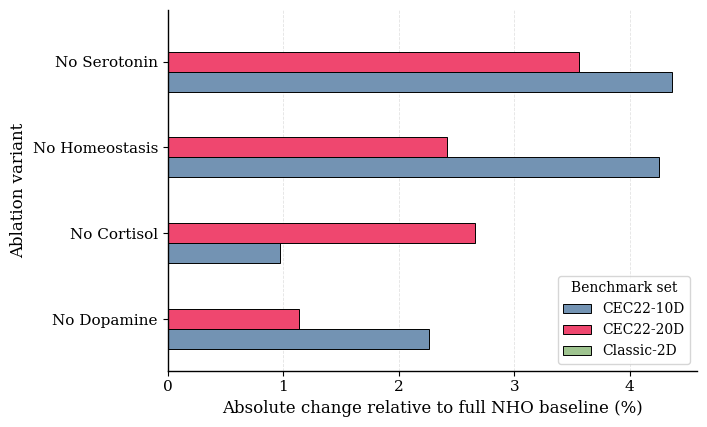

Saved files:
/content/drive/My Drive/Revision/history/ablation_analysis/figures/Figure_Ablation_Absolute_Relative_Impact.pdf
/content/drive/My Drive/Revision/history/ablation_analysis/figures/Figure_Ablation_Absolute_Relative_Impact.png
/content/drive/My Drive/Revision/history/ablation_analysis/figures/Figure_Ablation_Absolute_Relative_Impact.tiff


In [12]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Paths and definitions
# ------------------------------------------------------------
BASE_DIR = "/content/drive/My Drive/Revision/history/ablation_analysis"

SUITES = [
    "CEC22_selected-10D",
    "CEC22_selected-20D",
    "classic_selected-2D"
]

MODELS = [
    "NHO",
    "NHO_NoDopamine",
    "NHO_NoSerotonin",
    "NHO_NoCortisol",
    "NHO_NoHomeostasis"
]

MODEL_LABELS = {
    "NHO": "Full NHO",
    "NHO_NoDopamine": "No Dopamine",
    "NHO_NoSerotonin": "No Serotonin",
    "NHO_NoCortisol": "No Cortisol",
    "NHO_NoHomeostasis": "No Homeostasis"
}

SUITE_LABELS = {
    "CEC22_selected-10D": "CEC22-10D",
    "CEC22_selected-20D": "CEC22-20D",
    "classic_selected-2D": "Classic-2D"
}

# ------------------------------------------------------------
# 2. Q1-style matplotlib settings
# ------------------------------------------------------------
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 11,
    "axes.labelsize": 12,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,
    "axes.linewidth": 1.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})

# ------------------------------------------------------------
# 3. Robust CSV reader
# ------------------------------------------------------------
def extract_best_value_from_csv(csv_path):
    df = pd.read_csv(csv_path)

    possible_cols = [
        "best_fitness", "Best Fitness", "fitness", "Fitness",
        "best", "Best", "objective", "Objective",
        "global_best", "g_best"
    ]

    for col in possible_cols:
        if col in df.columns:
            values = pd.to_numeric(df[col], errors="coerce").dropna()
            if len(values) > 0:
                return values.iloc[-1]

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if len(numeric_cols) > 0:
        values = pd.to_numeric(df[numeric_cols[-1]], errors="coerce").dropna()
        if len(values) > 0:
            return values.iloc[-1]

    return np.nan

# ------------------------------------------------------------
# 4. Collect results
# ------------------------------------------------------------
records = []

for suite in SUITES:
    for model in MODELS:

        model_dir = os.path.join(BASE_DIR, suite, model)

        if not os.path.exists(model_dir):
            print(f"Directory not found: {model_dir}")
            continue

        csv_files = glob.glob(os.path.join(model_dir, "**", "*.csv"), recursive=True)

        values = []

        for csv_file in csv_files:
            try:
                value = extract_best_value_from_csv(csv_file)
                if not np.isnan(value):
                    values.append(value)
            except Exception as e:
                print(f"Could not read {csv_file}: {e}")

        if len(values) > 0:
            records.append({
                "Suite": suite,
                "Model": model,
                "MeanFitness": np.mean(values),
                "StdFitness": np.std(values),
                "NFiles": len(values)
            })

df = pd.DataFrame(records)

print("Collected results:")
display(df)

# ------------------------------------------------------------
# 5. Compute absolute relative change
# ------------------------------------------------------------
baseline_df = df[df["Model"] == "NHO"][["Suite", "MeanFitness"]]
baseline_df = baseline_df.rename(columns={"MeanFitness": "BaselineFitness"})

plot_df = df.merge(baseline_df, on="Suite", how="left")

plot_df["RelativeChange_%"] = (
    (plot_df["MeanFitness"] - plot_df["BaselineFitness"])
    / np.abs(plot_df["BaselineFitness"])
) * 100

plot_df["AbsoluteRelativeImpact_%"] = np.abs(plot_df["RelativeChange_%"])

plot_df = plot_df[plot_df["Model"] != "NHO"].copy()

plot_df["ModelLabel"] = plot_df["Model"].map(MODEL_LABELS)
plot_df["SuiteLabel"] = plot_df["Suite"].map(SUITE_LABELS)

display(plot_df)

# ------------------------------------------------------------
# 6. Pivot table for plotting
# ------------------------------------------------------------
pivot_df = plot_df.pivot(
    index="ModelLabel",
    columns="SuiteLabel",
    values="AbsoluteRelativeImpact_%"
)

pivot_df = pivot_df[["CEC22-10D", "CEC22-20D", "Classic-2D"]]

# Optional: order by average impact
pivot_df["Average"] = pivot_df.mean(axis=1)
pivot_df = pivot_df.sort_values("Average", ascending=True)
pivot_df = pivot_df.drop(columns=["Average"])

# ------------------------------------------------------------
# 7. Horizontal grouped bar plot
# ------------------------------------------------------------

colors = [
    "#7393B3",
    "#EF476F",
    "#9FC490"
]

fig, ax = plt.subplots(figsize=(7.2, 4.4))

pivot_df.plot(
    kind="barh",
    ax=ax,
    width=0.70,
    edgecolor="black",
    linewidth=0.7,
    color=colors
)

ax.set_xlabel(
    "Absolute change relative to full NHO baseline (%)",
    fontsize=12
)

ax.set_ylabel(
    "Ablation variant",
    fontsize=12
)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.6,
    alpha=0.35
)

ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Better tick appearance
ax.tick_params(axis='both', which='major', labelsize=11)

# Legend
ax.legend(
    title="Benchmark set",
    frameon=True,
    loc="lower right",
    edgecolor="0.8"
)

plt.tight_layout()

# ------------------------------------------------------------
# 8. Save figure
# ------------------------------------------------------------
SAVE_DIR = os.path.join(BASE_DIR, "figures")
os.makedirs(SAVE_DIR, exist_ok=True)

pdf_path = os.path.join(SAVE_DIR, "Figure_Ablation_Absolute_Relative_Impact.pdf")
png_path = os.path.join(SAVE_DIR, "Figure_Ablation_Absolute_Relative_Impact.png")
tiff_path = os.path.join(SAVE_DIR, "Figure_Ablation_Absolute_Relative_Impact.tiff")

plt.savefig(pdf_path, dpi=600, bbox_inches="tight")
plt.savefig(png_path, dpi=600, bbox_inches="tight")
plt.savefig(tiff_path, dpi=600, bbox_inches="tight")

plt.show()

print("Saved files:")
print(pdf_path)
print(png_path)
print(tiff_path)